In [33]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
import matplotlib.cm as cm
import matplotlib.colors as colors
import math
import time
import sys
import os
import json
from pathlib import Path

def galdtype_darksage(Nannuli=30,Nage=30):
    floattype = np.float32
    
    # Account for whether age bins are used for stars or not
    if Nage>1:
        disc_arr_dim = (Nannuli,Nage)
        bulge_arr_type = (floattype, Nage)
    else:
        disc_arr_dim = Nannuli
        bulge_arr_type = floattype

    Galdesc_full = [                                   
                    ('Type'                         , np.int32),
                    ('TypeMax'                      , np.int32),
                    ('GalaxyIndex'                  , np.int64),
                    ('HaloIndex'                    , np.int32),
                    ('SimulationHaloIndex'          , np.int32),
                    ('TreeIndex'                    , np.int32),
                    ('RootGalaxyIndex'              , np.int64),
                    ('SnapNum'                      , np.int32),
                    ('CentralGalaxyIndex'           , np.int64),
                    ('CentralMvir'                  , floattype),
                    ('mergeType'                    , np.int32),
                    ('mergeIntoID'                  , np.int64),
                    ('mergeIntoSnapNum'             , np.int32),
                    ('dT'                           , floattype),
                    ('Pos'                          , (floattype, 3)),
                    ('Vel'                          , (floattype, 3)),
                    ('Spin'                         , (floattype, 3)),
                    ('Len'                          , np.int64),
                    ('LenMax'                       , np.int64),
                    ('Mvir'                         , floattype),
                    ('Rvir'                         , floattype),
                    ('Vvir'                         , floattype),
                    ('Vmax'                         , floattype),
                    ('VelDisp'                      , floattype),
                    ('DiscRadii'                    , (floattype, Nannuli+1)), 
                    ('ColdGas'                      , floattype),
                    ('StellarMass'                  , floattype),
                    ('StellarFormationMass'         , bulge_arr_type),
                    ('ClassicalBulgeMass'           , bulge_arr_type),                    
                    ('SecularBulgeMass'             , bulge_arr_type),
                    ('StarsExSitu'                  , bulge_arr_type),
                    ('HotGas'                       , floattype),
                    ('FountainGas'                  , floattype),
                    ('OutflowGas'                   , floattype),
                    ('EjectedMass'                  , floattype),
                    ('LocalIGM'                     , floattype),
                    ('BlackHoleMass'                , floattype),
                    ('BlackHoleSpin'                , floattype),  
                    ('BH_Magnetization'             , floattype),  
                    ('BH_JetPower'                  , floattype), 
                    ('BH_JetEfficiency'                     , floattype),
                    ('BH_RadiativeEfficiency'       , floattype),                       
                    ('Eddrate'                      , floattype),
                    ('PrimaryBHMass'                      , floattype),
                    ('SecondaryBHMass'                      , floattype),
                    ('PrimaryBHSpin'                      , floattype),
                    ('SecondaryBHSpin'                      , floattype),
                    ('IntraClusterStars'            , bulge_arr_type),
                    ('LocalIGS'                     , bulge_arr_type),
                    ('DiscGas'                      , (floattype, Nannuli)),
                    ('DiscStars'                    , (floattype, disc_arr_dim)),
                    ('VelDispDiscStars'             , (floattype, disc_arr_dim)),
                    ('SpinStars'                    , (floattype, 3)),
                    ('SpinGas'                      , (floattype, 3)),
                    ('SpinClassicalBulge'              , (floattype, 3)),
                    ('StarsFromH2'                  , floattype),
                    ('StarsInstability'             , floattype),
                    ('StarsMergeBurst'              , floattype),
                    ('DiscHI'                       , (floattype, Nannuli)),
                    ('DiscH2'                       , (floattype, Nannuli)),
                    ('DiscSFR'                      , (floattype, Nannuli)), 
                    ('ICBHmass'                     , floattype),
                    ('ICBHnum'                      , np.int32),
                    ('LocalIGBHmass'                , floattype),
                    ('LocalIGBHnum'                 , np.int32),
                    ('VelDispInstabilityBulge'      , bulge_arr_type),
                    ('VelDispMergerBulge'           , floattype),
                    ('HalfMassRadiusInstabilityBulge', floattype),
                    ('HalfMassRadiusMergerBulge',     floattype),
                    ('HalfMassRadiusIntraClusterStars', floattype),
                    ('AverageEjectedRadius'         , floattype),
                    ('MetalsColdGas'                , floattype),
                    ('MetalsStellarMass'            , floattype),
                    ('ClassicalMetalsBulgeMass'        , bulge_arr_type),
                    ('SecularMetalsBulgeMass'   , bulge_arr_type),
                    ('MetalsStarsExSitu'            , bulge_arr_type),
                    ('MetalsHotGas'                 , floattype),
                    ('MetalsFountainGas'            , floattype),
                    ('MetalsOutflowGas'             , floattype),
                    ('MetalsEjectedMass'            , floattype),
                    ('MetalsLocalIGM'               , floattype),
                    ('MetalsIntraClusterStars'      , bulge_arr_type),
                    ('MetalsLocalIGS'               , bulge_arr_type),
                    ('DiscGasMetals'                , (floattype, Nannuli)),
                    ('DiscStarsMetals'              , (floattype, disc_arr_dim)),
                    ('SfrFromH2'                    , floattype),
                    ('SfrInstab'                    , floattype),
                    ('SfrMerge'                     , floattype),
                    ('SfrDiskZ'                     , floattype),
                    ('SfrBulgeZ'                    , floattype),
                    ('DiskScaleRadius'               , floattype),
                    ('CoolScaleRadius'              , floattype), 
                    ('StellarDiscScaleRadius'       , floattype),
                    ('GasDiscScaleRadius'           , floattype),
                    ('RotSupportScaleRadius'        , floattype),
                    ('Cooling'                      , floattype),
                    ('Heating'                      , floattype),
                    ('QuasarEnergy'                      , floattype),
                    ('AGNheating'                      , floattype),
                    ('AGNfountain'                      , floattype),  
                    ('CurrentRadioBlackHoleMass'                      , floattype),  
                    ('BHaccreted'                      , floattype),
                    ('BondiBHaccreted'                      , floattype),
                    ('RadioBHaccreted'                      , floattype),
                    ('InstaBHaccreted'                      , floattype),                    
                    ('RadioBlackHoleMass'                      , floattype),
                    ('InstaBlackHoleMass'                      , floattype),
                    ('MergerBlackHoleMass'                      , floattype),
                    ('Lbol'                      , floattype),
                    ('LastMajorMerger'              , floattype),
                    ('LastMinorMerger'              , floattype),
                    ('NumMajorMergers'              , np.int32),
                    ('NumMinorMergers'              , np.int32),
                    ('SNreheatRate'                 , floattype),
                    ('SNejectRate'                  , floattype),
                    ('infallMvir'                   , floattype),
                    ('infallVvir'                   , floattype),
                    ('infallVmax'                   , floattype)
                    ]
    names = [Galdesc_full[i][0] for i in range(len(Galdesc_full))]
    formats = [Galdesc_full[i][1] for i in range(len(Galdesc_full))]
    Galdesc = np.dtype({'names':names, 'formats':formats}, align=True)
    return Galdesc


def darksage_snap(fpre, filelist, fields=[], Nannuli=30, Nage=30):
    # Read full Dark Sage snapshot, going through each file and compiling into 1 array
    # fpre is the name of the file up until the _ before the file number
    # filelist contains all the file numbers you want to read in
    
    Galdesc = galdtype_darksage(Nannuli, Nage)
    NtotGalsSum = 0
    Gempty = np.empty(0, dtype=Galdesc)

    if len(fields)>0: 
        formats = []
        for field in fields:
            shape = Gempty[field].shape
            if len(shape)==1:
                formats += [Gempty[field].dtype]
            elif len(shape)==2:
                formats += [(Gempty[field].dtype, shape[1])]
            else:
                formats += [(Gempty[field].dtype, shape[1:])]
        Galdesc_reduced = np.dtype({'names':fields, 'formats':formats}, align=True)
        Gempty = np.empty(0, dtype=Galdesc_reduced)

    G_overhead_size = sys.getsizeof(Gempty)
    
    # First calculate the total number of galaxies that will fill the array
    bad_files = []
    for j, i in enumerate(filelist):
        try:
            fin = open(fpre+'_'+str(i), 'rb')
        except FileNotFoundError:
            print('Could not find file', i, 'skipping...')
            bad_files += [j]
            continue
        Ntrees = np.fromfile(fin,np.dtype(np.int32),1)  # Read number of trees in file
        NtotGals = np.fromfile(fin,np.dtype(np.int32),1)[0]        
        NtotGalsSum += NtotGals
        fin.close()

    print('NtotGalsSum =', NtotGalsSum)
#    print()
    print('Memory needed =', round((NtotGalsSum*(sys.getsizeof(np.empty(1,dtype=Gempty.dtype)) - G_overhead_size) + G_overhead_size) * 1e-9, 2), 'GB')
    G = np.empty(NtotGalsSum, dtype=Gempty.dtype) # Intialise the galaxy array
    NtotGalsSum = 0 # reset for next loop

    filelist = np.delete(filelist, bad_files)

    # Loop through files to fill in galaxy array
    for i in filelist:
#        print('reading file {0}'.format(i))
        fin = open(fpre+'_'+str(i), 'rb')
        Ntrees = np.fromfile(fin,np.dtype(np.int32),1)  # Read number of trees in file
        NtotGals = np.fromfile(fin,np.dtype(np.int32),1)[0]  # Read number of gals in file.
        GalsPerTree = np.fromfile(fin, np.dtype((np.int32, Ntrees)),1) # Read the number of gals in each tree
        G1 = np.fromfile(fin, Galdesc, NtotGals) # Read all the galaxy data
        fin.close()
        if len(fields)>0:
            G[NtotGalsSum:NtotGalsSum+NtotGals]  = G1[fields]
        else:
            G[NtotGalsSum:NtotGalsSum+NtotGals] = G1
        NtotGalsSum += NtotGals

    return G

#### Dictionaries
gal = {}
gal_dic = {}
     
def galaxy_sample( sample, data ):

    # Here we choose whether our sample should contain all galaxies, central galaxies only, or satellite galaxies only
    start = time.time()
    print('Loading data...')
    
    key=0
    for key in data.dtype.names:
        gal_dic[key] = list( data[key] )

    gal = pd.DataFrame( gal_dic )
    print('Time taking turning dataset to pandas dataframe: %f s.' % (time.time() - start) )

    if (sample == "centrals"):
        gal = gal.loc[ ( gal.Galaxy_Classification == 0 ) ]
        print( "You have chosen a sample of " + sample + "galaxies." )

    elif (sample == "satellites"):
        gal = gal.loc[ ( gal.Galaxy_Classification == 1 ) ]
        print( "You have chosen a sample of " + sample + "galaxies.")  

    else:
        print( "You have chosen a sample of " + sample + "galaxies.")

    return gal


def param_dicts( sample, data, h_hubble):

    gal = galaxy_sample( sample, data )
    # Vvir = gal.Vvir   
    # Rvir = gal.Rvir

    # gal['Bulge_Stellar_Mass'] = (gal.ClassicalBulgeMass + gal.SecularBulgeMass) / h
    # gal['Disk_Stellar_Mass'] = (gal.StellarMass - 
    #     gal.Bulge_Stellar_Mass) / h

    gal = gal.reset_index(drop=True)

    ## Summing up annuli properties
    start = time.time()
    print('Summing up annuli properties...')
    Total_Star_Formation_Rate = []
    # HI_Mass = []
    # H2_Mass = []
    Tot_ClassBulgeMass = []
    Tot_SecBulgeMass = []
    for i in range(len(gal.DiscSFR)):
        Total_DiscSFR = np.sum(gal.DiscSFR[i])
        # Total_HI_Mass = np.sum(gal.DiscHI[i])
        # Total_H2_Mass = np.sum(gal.DiscH2[i])
        Total_ClassicalBulgeMass = np.sum(gal.ClassicalBulgeMass[i])
        Total_SecularBulgeMass = np.sum(gal.SecularBulgeMass[i])

        Total_Star_Formation_Rate.append(Total_DiscSFR)
        # HI_Mass.append(Total_HI_Mass)
        # H2_Mass.append(Total_H2_Mass)
        Tot_ClassBulgeMass.append(Total_ClassicalBulgeMass)
        Tot_SecBulgeMass.append(Total_SecularBulgeMass)
        
    gal['Total_Star_Formation_Rate'] = Total_Star_Formation_Rate
    gal['Total_ClassicalBulgeMass'] = Tot_ClassBulgeMass
    gal['Total_SecularBulgeMass'] = Tot_SecBulgeMass
    # gal['HI_Mass'] = HI_Mass
    # gal['H2_Mass'] = H2_Mass
    print('Time: %f s.' % (time.time() - start) )

    # delete columns we don't need anymore to save space
    # gal = gal.drop(['DiscSFR', 'DiscHI', 'DiscH2', 'DiscRadii', 'DiscStars'], axis=1)

    ##### Adjustments. Multiplying by 1e10 for some parameters
    start = time.time()
    print('Lastly, converting to log form and multiplying by 1e10s...')

    gal['Total_Stellar_Mass'] = 1e10 * gal.StellarMass / h_hubble
    gal['Total_BulgeMass'] = 1e10*(gal['Total_ClassicalBulgeMass'] + gal['Total_SecularBulgeMass'])/h_hubble
    # gal.Disk_Stellar_Mass = 1e10 * gal.Disk_Stellar_Mass
    # gal.HI_Mass = 1e10 * gal.HI_Mass / h
    # gal.H2_Mass = 1e10 * gal.H2_Mass / h

    gal['Mvir'] = 1e10 * gal.Mvir / h_hubble
    gal['Cold_Gas_Mass'] = 1e10 * gal.ColdGas / h_hubble
    gal['Hot_Gas_Mass'] = 1e10 * gal.HotGas / h_hubble

    # Taking the log10 of these values
    gal['logsSFR'] = np.log10( gal.Total_Star_Formation_Rate / gal.Total_Stellar_Mass) 
    # this is to have all logsSFR values less than -12 to just be -12.0
    gal.loc[( gal.logsSFR < -12.0 ), 'logsSFR'] = -12.0    

    # Calculating morphology
    # gal['morph'] = gal.Disk_Stellar_Mass / gal.Total_Stellar_Mass

    # # Cold gas fraction
    # gal['CGM_SM'] = gal.Cold_Gas_Mass / gal.Total_Stellar_Mass


    gal['Black_Hole_Mass'] = 1e10 * gal.BlackHoleMass / h_hubble
    gal['logBHM'] = np.log10( gal.Black_Hole_Mass )
    # gal['t_dyn'] = 2. * np.pi * 1e6 * (gal.Rvir / gal.Vvir )

    logTSM = np.log10( gal.Total_Stellar_Mass )
    logMvir = np.log10( gal.Mvir )
    # logVmax = np.log10( gal.Vmax )
    # logCGM = np.log10( gal.Cold_Gas_Mass )
    # logHGM = np.log10( gal.Hot_Gas_Mass )
    gal['logTSM'] = logTSM
    gal['logMvir'] = logMvir 
    gal['logBulgeMass'] = np.log10(gal['Total_BulgeMass'])                                       
    # gal['logVmax'] = logVmax
    # gal['logCGM'] = logCGM
    # gal['logHGM'] = logHGM        
    # gal['logTSMvir'] = logTSMvir

    print('Time: %f s.' % (time.time() - start) ) 

    return gal


##################################################################################
#### #### #### #### #### #### this is when using stellar mass bins
def stellarmassbin( sample, data, lowmass, highmass, h_hubble):

    # This function calculates what we need for specified mass bin
    print( 'Breaking down data into stellar mass bin %s to %s' % (lowmass, highmass) )
    gal = param_dicts(sample, data, h_hubble)
    gal = gal.loc[ ( ( gal.logTSM <= highmass ) & \
        ( lowmass < gal.logTSM ) ) ]
    
    return gal


#### #### #### #### #### #### this is when using halo mass bins
def halomassbin( sample, data, lowmass, highmass, h_hubble):

    # This function calculates what we need for specified mass bin
    print( 'Breaking down data into halo mass bins %s to %s' % (lowmass, highmass) )
    gal = param_dicts(sample, data, h_hubble)
    gal = gal.loc[ ( ( gal.logMvir <= highmass ) & ( lowmass < gal.logMvir ) ) ]
    
    return gal

#### #### #### #### #### #### this function is used in our concentration calculation
def f( x ):
    p = np.log( 1.0 + x ) - x / ( 1.0 + x )
    
    return p

#### #### #### #### #### #### here we calculate our c parameter
def concentration( Vmax, Rvir, Mvir ):
    G = 4.32e-9
    k = Vmax**2.0 * Rvir / ( G * Mvir ) * 2.1626 / f( 2.1626 )
    func = lambda c : c / f( c ) - k 
    guess_init = 10.0
    c_solution = fsolve( func, guess_init )

    return c_solution[0]

#### #### #### #### #### #### here we integrate the NFW profile
def NFW( R, c, lowlim, highlim ):

    NFW_func = lambda r : 4.0 * np.pi * R * r**2.0 / ( ( r * c ) * 
        ( 1 + r * c / R )**2.0 )
    NFW_int, err = quad( NFW_func, lowlim, highlim )

    return NFW_int


def halospin( xspin, yspin, zspin, Vvir, Rvir ):

    # We are calculating Bullock's 2001 spin parameter for halo spin
    # Here we also include it as a column in our data set 
    HaloJ = np.sqrt( xspin**2 + yspin**2 + zspin**2 ) 
    hlambda = HaloJ / ( np.sqrt(2) * Vvir * Rvir )

    return hlambda


def discspin( discJ_tot, Vvir, Rvir ):

    # We are calculating Bullock's 2001 spin parameter for disc spin
    # Here we also include it as a column in our data set 
    slambda = discJ_tot / ( np.sqrt(2) * Vvir * Rvir )

    return slambda

def HIspin( HIJ_tot, Vvir, Rvir ):

    # We are calculating Bullock's 2001 spin parameter for disc spin
    # Here we also include it as a column in our data set 
    HIlambda = HIJ_tot / ( np.sqrt(2) * Vvir * Rvir )

    return HIlambda


def splitcol(df):
    df = df.astype(str)
    DF = df.str.strip('[]')
    DF = DF.str.split(expand=True)

    return DF


def interp_2Darray(xval, xarr, yarr, rising=True):   # Adam Steven's function
    # Linearly interpolate across each row of a 2D array with a corresponding 2D array for the same value
    # Currently assumes the function is always increasing at the point where it is to be interpolated
    (nrow, ncol) = xarr.shape
    (row, col) = np.where(xarr<xval) if rising else np.where(xarr>xval)
    filt = np.append(np.diff(row)>0, True)
    row, col = row[filt], col[filt]
    yout = np.zeros(nrow)
    row, col = row[col<ncol-1], col[col<ncol-1]
    gradient = (yarr[row,col+1]-yarr[row,col]) / (xarr[row,col+1]-xarr[row,col])
    yout[row] = yarr[row,col] + gradient * (xval - xarr[row,col])
    return yout


def main_code( sample, data, massbin, lowmass, highmass, h_hubble):

    # This describes morphology in terms of stellar mass
    if ( massbin == "stellarbin" ):
        gal = stellarmassbin( sample, data, lowmass, highmass, h_hubble)

    elif ( massbin == "halobin" ):
        gal = halomassbin( sample, data, lowmass, highmass, h_hubble)

    else:
        gal = param_dicts(sample, data, h_hubble)
 
    return gal


def stellar_mass_func( data, boxsize ):

    # Make a stellar mass function
    dmin = 6.9
    dmax = 12.1
    binwidth = 0.2
    Nbins = int( (dmax-dmin)/binwidth )
    bins = np.linspace( dmin, dmax, Nbins+1 )
    counts, edge = np.histogram( data, bins=bins )

    V       = ( boxsize )**3.0 #* Goodfiles / Treefiles      # for SAGE nocut
    dM      = edge[1] - edge[0]                             #Bin size
    bins    = edge[0:-1] + dM/2.                            #Mass axis
    Phi     = counts / float(V) / dM                        #Normalize to volume and bin size
    standard_dev = np.sqrt(counts) / float(V) / dM

    return Phi, bins, standard_dev



def blackhole_mass_func( data, boxsize ):

    # Make a stellar mass function
    dmin = 2.0
    dmax = 11.0
    binwidth = 0.2
    Nbins = int( (dmax-dmin)/binwidth )
    bins = np.linspace( dmin, dmax, Nbins+1 )
    counts, edge = np.histogram( data, bins=bins )

    #V       = ( boxsize )**3.0 / 2.0                      #Survey volume in Mpc3
    V       = ( boxsize )**3.0 #* Goodfiles / Treefiles      # for SAGE nocut
    dM      = edge[1] - edge[0]                             #Bin size
    bins    = edge[0:-1] + dM/2.                            #Mass axis
    Phi     = counts / float(V) / dM                        #Normalize to volume and bin size

    # Calculate the standard deviation in each bin
    std_func = np.nanstd
    idx = np.digitize( data, bins )
    standard_dev = np.sqrt(counts) / float(V) / dM

    return Phi, bins, standard_dev

def meanbin(a, b):
    idx_Mvir = np.digitize(a, Mvir_bins)
    mean_a = np.array([ mean_func(a[idx_Mvir==ii]) if len(a[idx_Mvir==ii]) > 10 else failval for ii in range(1, len(Mvir_bins))])
    mean_b = np.array([ mean_func(b[idx_Mvir==ii]) if len(a[idx_Mvir==ii]) > 10 else failval for ii in range(1, len(Mvir_bins))])
    return mean_a, mean_b



def stdbin(a, b):
    idx_Mvir = np.digitize(a, Mvir_bins)
    std_a = np.array([ std_func(a[idx_Mvir==ii])/np.sqrt(len(a[idx_Mvir==ii])) if len(a[idx_Mvir==ii]) > 10 else failval for ii in range(1, len(Mvir_bins))])
    std_b = np.array([ std_func(b[idx_Mvir==ii])/np.sqrt(len(b[idx_Mvir==ii])) if len(a[idx_Mvir==ii]) > 10 else failval for ii in range(1, len(Mvir_bins))])

    #std_meanb = np.array(std_b/np.sqrt(len(b[idx_Mvir==k])) for k in range(1, len(Mvir_bins)))
    return std_a, std_b


def medianbin(a, b):
    idx_Mvir = np.digitize(a, Mvir_bins)
    median_a = np.array([ median_func(a[idx_Mvir==ii]) if len(a[idx_Mvir==ii]) > 10 else failval for ii in range(1, len(Mvir_bins))])
    median_b = np.array([ median_func(b[idx_Mvir==ii]) if len(a[idx_Mvir==ii]) > 10 else failval for ii in range(1, len(Mvir_bins))])
    
    return median_a, median_b


def percentile(a, b):
    marks_dict = {}

    idx_Mvir = np.digitize(a, Mvir_bins)
    perc = [ 68.0, 95.0, 99.7 ]

    for i in range( len( perc ) ):
        perc_lims = [ 50.0 - ( perc[i]/2. ), 50.0 + ( perc[i]/2. ) ]
        mark_lower = np.array([ percentile_func(b[idx_Mvir==ii], perc_lims[0] ) if len(a[idx_Mvir==ii]) > 10 else failval for ii in range(1, len(Mvir_bins))])
        mark_upper = np.array([ percentile_func(b[idx_Mvir==ii], perc_lims[1] ) if len(a[idx_Mvir==ii]) > 10 else failval for ii in range(1, len(Mvir_bins))])
        mark_lims = [ mark_lower, mark_upper ]
        marks_dict[i] = mark_lims

    return marks_dict



def interp_2Darray(xval, xarr, yarr, rising=True):   # Adam Steven's function
    # Linearly interpolate across each row of a 2D array with a corresponding 2D array for the same value
    # Currently assumes the function is always increasing at the point where it is to be interpolated
    (nrow, ncol) = xarr.shape
    (row, col) = np.where(xarr<xval) if rising else np.where(xarr>xval)
    filt = np.append(np.diff(row)>0, True)
    row, col = row[filt], col[filt]
    yout = np.zeros(nrow)
    row, col = row[col<ncol-1], col[col<ncol-1]
    gradient = (yarr[row,col+1]-yarr[row,col]) / (xarr[row,col+1]-xarr[row,col])
    yout[row] = yarr[row,col] + gradient * (xval - xarr[row,col])
    return yout

###### USER NEEDS TO SET THESE THINGS ######
indir = '/home/nicho/DarkSAGE/mini_millenium/'

field = ['Type', 'GalaxyIndex', 'Mvir', 'DiscSFR', 'HotGas', 'ColdGas', 'StellarMass', 
    'BlackHoleMass', 'BlackHoleSpin', 'BHaccreted', 'Eddrate', 'Lbol', 
    'ClassicalBulgeMass', 'SecularBulgeMass', 'DiscStars', 'DiscRadii', 'DiscHI', 
    'DiscH2', 'Heating', 'QuasarEnergy', 'AGNfountain']

Nannuli = 30 # number of annuli used for discs in Dark Sage
Nage = 30 # number of age bins used for stars -- should only be used for calibrating when delayed feedback is on

files = range(8)

fpre_list = [
    'model_z0.000',
    'model_z1.000',
    'model_z2.000',
    'model_z3.010',
    'model_z4.010',
    'model_z5.000',
    'model_z6.010',
]
z_labels = ['z0', 'z1', 'z2', 'z3', 'z4', 'z5', 'z6']
start = time.time()

data_z0_0  = darksage_snap(indir  + fpre_list[0], files, fields=field, Nannuli=Nannuli, Nage=Nage)


massbin = "stellarbin"                                                          # Options: "stellarbin" or "halobin" or " "
sample = "all"                                                                  # Options: 'all' , 'centrals', 'satellites'
lowmassbin = 0.0                                                                # lower mass bin for either stellar mass or halo mass
highmassbin = 13.0                                                              # higher mass bin for either stellar mass or halo mass
h_hubble = 0.6774   

# ── main_code calls ────────────────────────────────────────────────────────────
gal_fid                = main_code("all", data_z0_0,  massbin, lowmassbin, highmassbin, h_hubble)


NtotGalsSum = 35054
Memory needed = 0.15 GB
Breaking down data into stellar mass bin 0.0 to 13.0
Loading data...
Time taking turning dataset to pandas dataframe: 0.105096 s.
You have chosen a sample of allgalaxies.
Summing up annuli properties...
Time: 1.209900 s.
Lastly, converting to log form and multiplying by 1e10s...
Time: 0.005095 s.


/home/nicho/miniconda3/envs/astro2/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/nicho/miniconda3/envs/astro2/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [34]:
gal_fid

,Type,GalaxyIndex,Mvir,DiscSFR,HotGas,ColdGas,StellarMass,BlackHoleMass,BlackHoleSpin,BHaccreted,...,Total_Stellar_Mass,Total_BulgeMass,Cold_Gas_Mass,Hot_Gas_Mass,logsSFR,Black_Hole_Mass,logBHM,logTSM,logMvir,logBulgeMass
0,0,0,5.315896e+13,"[0.0, 0.0, 3.135571e-08, 9.774751e-08, 2.65501...",419.882538,12.408828,6.931898e+01,7.430305e-04,-0.499308,7.796231e-04,...,1.023309e+12,7.503319e+11,1.831832e+11,6.198443e+12,-10.494158,1.096886e+07,7.040162,12.010007,13.725576,11.875254
1,1,299,2.965286e+12,"[0.0016222592, 0.006975699, 0.013819248, 0.016...",1.927541,6.870444,2.436638e+01,4.734594e-03,0.012210,1.086524e-03,...,3.597045e+11,5.753420e+10,1.014237e+11,2.845499e+10,-10.379213,6.989362e+07,7.844438,11.555946,12.472067,10.759926
2,1,258,2.210722e+11,"[3.476967e-05, 3.116914e-05, 6.023905e-05, 0.0...",0.000813,0.605749,2.310228e+00,2.123314e-08,-0.503222,3.358572e-10,...,3.410434e+10,3.908754e+09,8.942264e+09,1.199727e+07,-10.242213,3.134506e+02,2.496169,10.532809,11.344534,9.592038
3,1,296,1.698195e+11,"[0.0006735551, 0.00028368869, 0.00066301797, 0...",0.000220,0.366157,1.260018e+00,9.265724e-07,0.822890,0.000000e+00,...,1.860079e+10,4.038073e+07,5.405324e+09,3.252146e+06,-10.367351,1.367836e+04,4.136034,10.269531,11.229987,7.606174
4,1,321,1.344644e+11,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.708922,0.053731,4.594691e-01,3.092802e-08,0.505404,4.412927e-11,...,6.782832e+09,1.016977e+08,7.931937e+08,1.046534e+10,-12.000000,4.565695e+02,2.659507,9.831411,11.128607,8.007311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35048,0,70003420000000000,1.651688e+10,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 7.6215425e...",0.018129,0.016834,8.902730e-08,1.001256e-08,-0.000000,2.036695e-10,...,1.314250e+03,0.000000e+00,2.485057e+08,2.676192e+08,-8.719161,1.478087e+02,2.169700,3.118678,10.217928,-inf
35049,0,70003421000000000,1.651688e+10,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.624259e-08, 1...",0.017438,0.017523,4.871740e-07,1.001250e-08,0.000000,2.036960e-10,...,7.191822e+03,0.000000e+00,2.586836e+08,2.574313e+08,-8.397919,1.478078e+02,2.169697,3.856839,10.217928,-inf
35051,0,70003423000000000,1.397583e+10,"[0.0, 0.0, 2.0038224e-08, 8.701653e-08, 3.4662...",0.000000,0.062354,2.119047e-04,1.003515e-08,-0.000000,1.750090e-10,...,3.128206e+06,0.000000e+00,9.204878e+08,0.000000e+00,-9.009563,1.481421e+02,2.170679,6.495296,10.145377,-inf
35052,0,70003424000000000,1.905794e+10,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.042143,0.006045,1.961498e-09,1.000407e-08,-0.000000,2.117427e-10,...,2.895627e+01,0.000000e+00,8.924034e+07,6.221224e+08,-8.453053,1.476833e+02,2.169332,1.461743,10.280076,-inf


In [35]:
gal_fid.logBHM

0        7.040162
1        7.844438
2        2.496169
3        4.136034
4        2.659507
           ...   
35048    2.169700
35049    2.169697
35051    2.170679
35052    2.169332
35053    2.170674
Name: logBHM, Length: 34193, dtype: float32

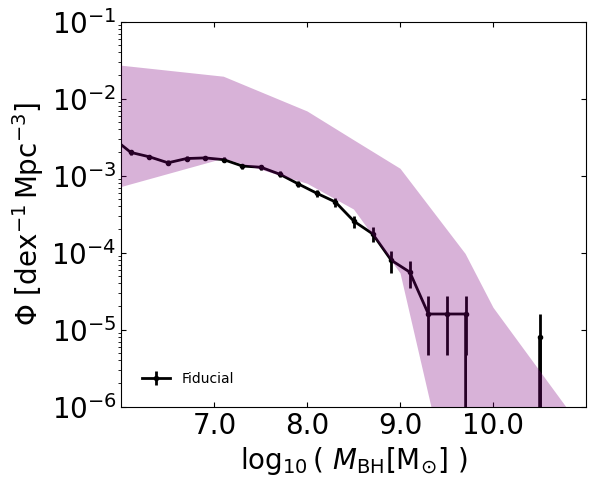

In [36]:

# ── black-hole mass-function plot + reproducible exports ─────────────────────
# Running this cell writes both the publication-style figure and the binned mass
# function values used to make it.

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif (PROJECT_ROOT / "notebooks" / "Mass_function_plotting.ipynb").exists():
    PROJECT_ROOT = PROJECT_ROOT
else:
    # Fallback for unusual notebook launch directories.
    PROJECT_ROOT = Path("/home/nicho/DarkSAGE")

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "mass_function"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PDF_PATH = OUTPUT_DIR / "BHMF_all_fid_z0.pdf"
CSV_PATH = OUTPUT_DIR / "BHMF_all_fid_z0_mass_function.csv"
JSON_PATH = OUTPUT_DIR / "BHMF_all_fid_z0_metadata.json"


def blackhole_mass_function_table(data, boxsize, dmin=2.0, dmax=11.0, binwidth=0.2):
    """Return the binned BH mass function as a DataFrame."""
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    edges = np.arange(dmin, dmax + 0.5 * binwidth, binwidth)
    counts, edges = np.histogram(data, bins=edges)
    centers = edges[:-1] + 0.5 * np.diff(edges)
    volume_mpc3 = float(boxsize) ** 3.0
    width = np.diff(edges)
    phi = counts / volume_mpc3 / width
    phi_err = np.sqrt(counts) / volume_mpc3 / width
    out = pd.DataFrame(
        {
            "label": "",
            "log10_mbh_bin_left": edges[:-1],
            "log10_mbh_bin_center": centers,
            "log10_mbh_bin_right": edges[1:],
            "bin_width_dex": width,
            "count": counts.astype(int),
            "volume_mpc3": volume_mpc3,
            "phi_dex_mpc3": phi,
            "phi_err_dex_mpc3": phi_err,
        }
    )
    out["log10_phi"] = np.where(out["phi_dex_mpc3"] > 0, np.log10(out["phi_dex_mpc3"]), np.nan)
    out["log10_phi_err"] = np.where(out["phi_err_dex_mpc3"] > 0, np.log10(out["phi_err_dex_mpc3"]), np.nan)
    return out


df_ar = [gal_fid]
label_ar = ["Fiducial"]
color_ar = ["black"]

size_label = 20
size_legend = 10
size_ticks = 20
dot_size = 11

h = 0.73
boxsize = 62.5 / h

mass_function_tables = []

plt.clf()
plt.close()
f, ax1 = plt.subplots(1, sharex=False, sharey=False, figsize=(6, 5))
ax1.set_facecolor("white")

for zz, (df_i, color_i, label_i) in enumerate(zip(df_ar, color_ar, label_ar)):
    mf_i = blackhole_mass_function_table(df_i.logBHM, boxsize)
    mf_i["label"] = label_i
    mass_function_tables.append(mf_i)

    ax1.errorbar(
        mf_i["log10_mbh_bin_center"],
        mf_i["phi_dex_mpc3"],
        yerr=mf_i["phi_err_dex_mpc3"],
        linestyle="-",
        color=color_i,
        marker=".",
        label=label_i,
        lw=2.0,
    )

# Observations: empirical envelope from the BHMF z=0 plot.
ax1.fill_between(
    [6.0, 7.1, 8.0, 8.5, 9.0, 9.7, 10.0, 11.0],
    [10**-1.5727, 10**-1.7159, 10**-2.1672, 10**-2.5406, 10**-2.9116, 10**-4.0177, 10**-4.7171, 10**-6.3643],
    [10**-3.1483, 10**-2.7793, 10**-3.1063, 10**-3.4410, 10**-4.2700, 10**-7.9231, 10**-8.9543, 10**-9.5019],
    facecolor="purple",
    alpha=0.3,
    label="",
    zorder=10,
)

ax1.set_ylabel(r"$\Phi\ [\mathrm{dex}^{-1}\,\mathrm{Mpc}^{-3} ] $", fontsize=size_label)
ax1.set_yscale("log")
ax1.set_ylim((10**-6, 10**-1))

ax1.set_xlabel(r"$\log_{10}( \ M_{\rm BH} [\mathrm{M}_{\odot}]\ )$", fontsize=size_label)
ax1.set_xlim(6.0, 11.0)
ax1.set_xticks([7.0, 8.0, 9.0, 10.0])
ax1.set_xticklabels([7.0, 8.0, 9.0, 10.0], fontsize=size_ticks)

ax1.tick_params(axis="both", which="major", labelsize=size_ticks)
ax1.tick_params(axis="both", which="minor", labelsize=size_ticks)
ax1.tick_params(axis="y", direction="in", right=True)
ax1.tick_params(axis="x", direction="in", top=True)

ax1.legend(
    frameon=False,
    framealpha=1,
    borderpad=1,
    labelspacing=0.3,
    edgecolor="k",
    fontsize=size_legend,
    facecolor="white",
    loc=3,
)

f.savefig(PDF_PATH, bbox_inches="tight")
mass_function_df = pd.concat(mass_function_tables, ignore_index=True)
mass_function_df.to_csv(CSV_PATH, index=False)

metadata = {
    "figure_pdf": str(PDF_PATH),
    "mass_function_csv": str(CSV_PATH),
    "boxsize_mpc": boxsize,
    "h_for_boxsize": h,
    "mass_function": "black_hole_mass_function",
    "x_column": "log10_mbh_bin_center",
    "y_column": "phi_dex_mpc3",
    "y_error_column": "phi_err_dex_mpc3",
    "bin_width_dex": 0.2,
    "labels": label_ar,
}
JSON_PATH.write_text(json.dumps(metadata, indent=2) + "\n")

print(f"Wrote figure: {PDF_PATH}")
print(f"Wrote mass function table: {CSV_PATH}")
print(f"Wrote metadata: {JSON_PATH}")

plt.show()
mass_function_df.head()


## LSST AGN Variability Detectability

Use the z=0 DarkSAGE AGN sample as the low-redshift ($z < 0.1$) population. For each loaded BHMF sample, this section estimates the asymptotic damped-random-walk structure-function amplitude, compares it to the LSST single-visit random photometric error, counts detected AGN, and plots the distribution of $SF_\infty$.


In [ ]:
# -- LSST variability detectability for z < 0.1 AGN --------------------------
# This follows the MacLeod-style scaling shown in the notes:
# log10(SF_inf / mag) = A + B log10(lambda_RF / 4000 A)
#                       + C (M_i + 23) + D log10(M_BH / 1e9 Msun).
# The z=0 snapshot is used here as the z < 0.1 sample. Because the snapshot
# itself has no per-object observed redshift, DETECTION_REDSHIFT sets the
# fiducial distance for converting M_i to apparent m_i for the LSST noise. The paper uses total single-visit precision sigma_1, including sigma_sys.

from astropy.cosmology import FlatLambdaCDM

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd().resolve()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent
    elif not (PROJECT_ROOT / "notebooks" / "Mass_function_plotting.ipynb").exists():
        PROJECT_ROOT = Path("/home/nicho/DarkSAGE")

VARIABILITY_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "mass_function"
VARIABILITY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DETECTION_REDSHIFT = 0.05
REST_WAVELENGTH_A = 4000.0  # fixed so B * log10(lambda_RF / 4000 A) = 0
LSST_G_M5 = 25.0
LSST_G_GAMMA = 0.039
LSST_SIGMA_SYS_MAG = 0.005
LSST_BRIGHT_LIMIT_MAG = 16.0
LSST_FAINT_LIMIT_MAG = 25.0
SF_COEFFS = {"A": -0.51, "B": -0.479, "C": 0.131, "D": 0.18}
LOG_LBOL_ERG_S_RANGE = (41.0, 46.0)
cosmo = FlatLambdaCDM(H0=100.0 * h_hubble, Om0=0.3089)


def bolometric_luminosity_erg_s(lbol_input):
    """Return Lbol in erg/s from DarkSAGE Lbol-like values.

    In the current DarkSAGE Mini-Millennium output, Lbol is already stored as
    log10(Lbol / erg s^-1), e.g. 41--47. This helper also accepts linear erg/s
    or linear W values so the cell is reusable for other outputs.
    """
    raw = np.asarray(lbol_input, dtype=float)
    out = np.full(raw.shape, np.nan, dtype=float)
    finite = np.isfinite(raw)

    looks_like_log_erg_s = finite & (raw > 20.0) & (raw < 60.0)
    looks_like_linear_erg_s = finite & (raw >= 1.0e35)
    looks_like_linear_watt = finite & (raw > 0.0) & (raw < 1.0e35) & ~looks_like_log_erg_s

    out[looks_like_log_erg_s] = 10.0 ** raw[looks_like_log_erg_s]
    out[looks_like_linear_erg_s] = raw[looks_like_linear_erg_s]
    out[looks_like_linear_watt] = raw[looks_like_linear_watt] * 1.0e7
    return out


def infer_lbol_interpretation(lbol_input):
    raw = np.asarray(lbol_input, dtype=float)
    finite = raw[np.isfinite(raw)]
    if finite.size == 0:
        return "unknown_empty"
    med = float(np.nanmedian(finite))
    if 20.0 < med < 60.0:
        return "log10_erg_s"
    if med >= 1.0e35:
        return "linear_erg_s"
    return "linear_watt"


def absolute_i_from_lbol(lbol_erg_s):
    """Approximate absolute i magnitude from bolometric luminosity."""
    return 90.0 - 2.5 * np.log10(lbol_erg_s)


def apparent_i_from_absolute_i(M_i, redshift=DETECTION_REDSHIFT):
    distance_modulus = cosmo.distmod(redshift).value
    return M_i + distance_modulus


def lsst_random_photometric_error_mag(mag, m5=LSST_G_M5, gamma=LSST_G_GAMMA):
    x = 10.0 ** (0.4 * (np.asarray(mag, dtype=float) - m5))
    sigma2 = (0.04 - gamma) * x + gamma * x**2
    return np.sqrt(np.maximum(sigma2, 0.0))


def sf_inf_drw_mag(M_i, M_bh_msun, rest_wavelength_a=REST_WAVELENGTH_A, coeffs=SF_COEFFS):
    log_sf = (
        coeffs["A"]
        + coeffs["B"] * np.log10(rest_wavelength_a / 4000.0)
        + coeffs["C"] * (M_i + 23.0)
        + coeffs["D"] * np.log10(M_bh_msun / 1.0e9)
    )
    return 10.0 ** log_sf


def variability_detectability_table(df, label):
    work = df.copy()
    lbol_raw = work["Lbol"].to_numpy(dtype=float)
    lbol_erg_s = bolometric_luminosity_erg_s(lbol_raw)
    mbh_msun = work["Black_Hole_Mass"].to_numpy(dtype=float)
    log_lbol_erg_s = np.full(lbol_erg_s.shape, np.nan, dtype=float)
    positive_lbol = np.isfinite(lbol_erg_s) & (lbol_erg_s > 0)
    log_lbol_erg_s[positive_lbol] = np.log10(lbol_erg_s[positive_lbol])
    valid = (
        np.isfinite(log_lbol_erg_s)
        & np.isfinite(mbh_msun)
        & (mbh_msun > 0)
        & (log_lbol_erg_s >= LOG_LBOL_ERG_S_RANGE[0])
        & (log_lbol_erg_s <= LOG_LBOL_ERG_S_RANGE[1])
    )
    work = work.loc[valid].copy()
    lbol_raw = lbol_raw[valid]
    lbol_erg_s = lbol_erg_s[valid]
    log_lbol_erg_s = log_lbol_erg_s[valid]
    mbh_msun = mbh_msun[valid]

    M_i = absolute_i_from_lbol(lbol_erg_s)
    m_i = apparent_i_from_absolute_i(M_i)
    sf_inf = sf_inf_drw_mag(M_i, mbh_msun)
    sigma_rand = lsst_random_photometric_error_mag(m_i)
    sigma_1 = np.sqrt(LSST_SIGMA_SYS_MAG**2 + sigma_rand**2)
    in_lsst_mag_range = (m_i > LSST_BRIGHT_LIMIT_MAG) & (m_i < LSST_FAINT_LIMIT_MAG)

    physical = (
        np.isfinite(M_i)
        & np.isfinite(m_i)
        & np.isfinite(sf_inf)
        & np.isfinite(sigma_rand)
        & np.isfinite(sigma_1)
        & (sf_inf > 0.0)
        & (sf_inf < 10.0)
        & (sigma_rand > 0.0)
        & (sigma_rand < 10.0)
        & (sigma_1 > 0.0)
        & (sigma_1 < 10.0)
    )
    work = work.loc[physical].copy()

    work["sample_label"] = label
    work["Lbol_raw"] = lbol_raw[physical]
    work["Lbol_input_interpretation"] = infer_lbol_interpretation(lbol_raw)
    work["Lbol_erg_s"] = lbol_erg_s[physical]
    work["log10_Lbol_erg_s"] = log_lbol_erg_s[physical]
    work["M_i"] = M_i[physical]
    work["m_i_at_detection_redshift"] = m_i[physical]
    work["SF_inf_mag"] = sf_inf[physical]
    work["sigma_rand_mag"] = sigma_rand[physical]
    work["sigma_1_mag"] = sigma_1[physical]
    work["SF_inf_lim_LSST_mag"] = sigma_rand[physical]
    work["in_lsst_mag_range"] = in_lsst_mag_range[physical]
    work["variability_detected"] = (sf_inf[physical] > sigma_rand[physical]) & in_lsst_mag_range[physical]
    return work


# Load all three z=0 BHMF runs when available, because the variability
# calculation needs per-object BH masses and Lbol rather than the binned BHMF CSVs.
VARIABILITY_BHMF_RUNS = [
    ("Fiducial", PROJECT_ROOT / "all_mass_functions" / "Fid"),
    ("Heavy seed", PROJECT_ROOT / "all_mass_functions" / "Heavy"),
    ("Power-law seed", PROJECT_ROOT / "all_mass_functions" / "Power Law"),
]

if all((run_dir / "model_z0.000_0").is_file() for _, run_dir in VARIABILITY_BHMF_RUNS):
    variability_samples = []
    for label_i, run_dir in VARIABILITY_BHMF_RUNS:
        print(f"Loading z=0 DarkSAGE sample for {label_i}: {run_dir}")
        data_i = darksage_snap(
            str(run_dir / "model_z0.000"),
            files,
            fields=field,
            Nannuli=Nannuli,
            Nage=Nage,
        )
        gal_i = main_code("all", data_i, massbin, lowmassbin, highmassbin, h_hubble)
        variability_samples.append((label_i, gal_i))
else:
    # Fallback for a copied notebook that only has the fiducial Mini-Millennium
    # run available.
    try:
        variability_samples = list(zip(label_ar, df_ar))
    except NameError:
        variability_samples = [("Fiducial", gal_fid)]

variability_tables = [variability_detectability_table(df_i, label_i) for label_i, df_i in variability_samples]
variability_df = pd.concat(variability_tables, ignore_index=True)

if variability_df.empty:
    raise RuntimeError("No finite, physical AGN entries after Lbol/BH-mass validation.")

detection_summary = (
    variability_df.groupby("sample_label", sort=False)
    .agg(
        n_agn=("variability_detected", "size"),
        n_detected=("variability_detected", "sum"),
        median_SF_inf_mag=("SF_inf_mag", "median"),
        p16_SF_inf_mag=("SF_inf_mag", lambda x: np.nanpercentile(x, 16)),
        p84_SF_inf_mag=("SF_inf_mag", lambda x: np.nanpercentile(x, 84)),
        median_sigma_rand_mag=("sigma_rand_mag", "median"),
        median_sigma_1_mag=("sigma_1_mag", "median"),
        n_in_lsst_mag_range=("in_lsst_mag_range", "sum"),
    )
    .reset_index()
)
detection_summary["detected_fraction"] = detection_summary["n_detected"] / detection_summary["n_agn"]

variability_csv = VARIABILITY_OUTPUT_DIR / "zlt0p1_lsst_variability_detectability.csv"
summary_csv = VARIABILITY_OUTPUT_DIR / "zlt0p1_lsst_variability_detection_summary.csv"
hist_pdf = VARIABILITY_OUTPUT_DIR / "zlt0p1_lsst_sf_inf_histogram.pdf"
metadata_path = VARIABILITY_OUTPUT_DIR / "zlt0p1_lsst_variability_metadata.json"

variability_df.to_csv(variability_csv, index=False)
detection_summary.to_csv(summary_csv, index=False)
metadata_path.write_text(json.dumps({
    "redshift_selection": "z=0 DarkSAGE snapshot used as z < 0.1 sample",
    "detection_redshift_for_apparent_magnitude": DETECTION_REDSHIFT,
    "rest_wavelength_A": REST_WAVELENGTH_A,
    "lsst_g_m5": LSST_G_M5,
    "lsst_g_gamma": LSST_G_GAMMA,
    "lsst_sigma_sys_mag": LSST_SIGMA_SYS_MAG,
    "lsst_bright_limit_mag": LSST_BRIGHT_LIMIT_MAG,
    "lsst_faint_limit_mag": LSST_FAINT_LIMIT_MAG,
    "sf_inf_coefficients": SF_COEFFS,
    "mi_formula": "M_i = 90 - 2.5 log10(Lbol[erg/s])",
    "lbol_input_handling": "Values between 20 and 60 are interpreted as log10(Lbol[erg/s]); very large values as linear erg/s; smaller positive values as W and converted to erg/s.",
    "log_lbol_erg_s_selection": LOG_LBOL_ERG_S_RANGE,
    "detection_rule": "(SF_inf_mag > sigma_rand_mag) and (16 < apparent magnitude < 25)",
    "samples": [label for label, _ in variability_samples],
}, indent=2) + "\n")

plt.close("all")
fig, ax = plt.subplots(figsize=(7, 5))
max_sf = min(2.0, max(0.5, float(np.nanpercentile(variability_df["SF_inf_mag"], 99.5))))
bins = np.linspace(0.0, max_sf, 40)
for label_i, _ in variability_samples:
    vals = variability_df.loc[variability_df["sample_label"] == label_i, "SF_inf_mag"]
    ax.hist(vals, bins=bins, histtype="step", linewidth=2.0, label=label_i)
ax.axvline(
    np.nanmedian(variability_df["sigma_1_mag"]),
    color="0.35",
    linestyle="--",
    label="median LSST sigma_1",
)
ax.set_xlabel(r"$SF_\infty$ [mag rms]")
ax.set_ylabel("Number of AGN")
ax.set_title(r"Low-redshift AGN variability amplitude, $z < 0.1$")
ax.legend(frameon=False)
fig.savefig(hist_pdf, bbox_inches="tight")

print(f"Wrote object table: {variability_csv}")
print(f"Wrote detection summary: {summary_csv}")
print(f"Wrote histogram: {hist_pdf}")
print(f"Wrote metadata: {metadata_path}")
try:
    display(detection_summary)
except NameError:
    print(detection_summary)
plt.show()


## Three Black-Hole Mass Functions

Plot the fiducial, heavy-seed, and power-law-seed z=0 black-hole mass functions together using the mass-function tables stored in `all_mass_functions`.


In [ ]:
# -- three black-hole mass functions from all_mass_functions -------------------
# This cell uses the z=0 mass-function tables in DarkSAGE/all_mass_functions and
# makes the same style of plot as the single-fiducial BHMF cell above.

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "notebooks" / "Mass_function_plotting.ipynb").exists():
    PROJECT_ROOT = Path("/home/nicho/DarkSAGE")

THREE_BHMF_INPUT_DIR = PROJECT_ROOT / "all_mass_functions"
THREE_BHMF_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "mass_function"
THREE_BHMF_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

THREE_BHMF_RUNS = [
    {
        "label": "Fiducial",
        "path": THREE_BHMF_INPUT_DIR / "Fid" / "BHMF_all_fid_z0_mass_function.csv",
        "color": "black",
    },
    {
        "label": "Heavy seed",
        "path": THREE_BHMF_INPUT_DIR / "Heavy" / "BHMF_all_heavy_z0_mass_function.csv",
        "color": "tab:red",
    },
    {
        "label": "Power-law seed",
        "path": THREE_BHMF_INPUT_DIR / "Power Law" / "BHMF_all_power_law_z0_mass_function.csv",
        "color": "tab:blue",
    },
]

missing = [str(run["path"]) for run in THREE_BHMF_RUNS if not run["path"].is_file()]
if missing:
    raise FileNotFoundError("Missing mass-function table(s):\n" + "\n".join(missing))

three_bhmf_tables = []
plt.clf()
plt.close()
fig, ax = plt.subplots(1, sharex=False, sharey=False, figsize=(6, 5))
ax.set_facecolor("white")

for run in THREE_BHMF_RUNS:
    mf = pd.read_csv(run["path"])
    mf = mf.copy()
    mf["label"] = run["label"]
    three_bhmf_tables.append(mf)

    positive = mf["phi_dex_mpc3"].to_numpy(dtype=float) > 0
    ax.errorbar(
        mf.loc[positive, "log10_mbh_bin_center"],
        mf.loc[positive, "phi_dex_mpc3"],
        yerr=mf.loc[positive, "phi_err_dex_mpc3"],
        linestyle="-",
        color=run["color"],
        marker=".",
        label=run["label"],
        lw=2.0,
    )

# Observations: same empirical envelope used in the single-BHMF plot above.
ax.fill_between(
    [6.0, 7.1, 8.0, 8.5, 9.0, 9.7, 10.0, 11.0],
    [10**-1.5727, 10**-1.7159, 10**-2.1672, 10**-2.5406, 10**-2.9116, 10**-4.0177, 10**-4.7171, 10**-6.3643],
    [10**-3.1483, 10**-2.7793, 10**-3.1063, 10**-3.4410, 10**-4.2700, 10**-7.9231, 10**-8.9543, 10**-9.5019],
    facecolor="purple",
    alpha=0.3,
    label="observational envelope",
    zorder=0,
)

ax.set_ylabel(r"$\Phi\ [\mathrm{dex}^{-1}\,\mathrm{Mpc}^{-3} ] $", fontsize=size_label)
ax.set_yscale("log")
ax.set_ylim((10**-6, 10**-1))
ax.set_xlabel(r"$\log_{10}( \ M_{\rm BH} [\mathrm{M}_{\odot}]\ )$", fontsize=size_label)
ax.set_xlim(6.0, 11.0)
ax.set_xticks([7.0, 8.0, 9.0, 10.0])
ax.set_xticklabels([7.0, 8.0, 9.0, 10.0], fontsize=size_ticks)
ax.tick_params(axis="both", which="major", labelsize=size_ticks, direction="in", top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", top=True, right=True)
ax.legend(frameon=False, fontsize=size_legend, loc="best")
fig.tight_layout()

three_bhmf_csv = THREE_BHMF_OUTPUT_DIR / "BHMF_three_seed_models_z0_mass_function.csv"
three_bhmf_pdf = THREE_BHMF_OUTPUT_DIR / "BHMF_three_seed_models_z0.pdf"
three_bhmf_json = THREE_BHMF_OUTPUT_DIR / "BHMF_three_seed_models_z0_metadata.json"

pd.concat(three_bhmf_tables, ignore_index=True).to_csv(three_bhmf_csv, index=False)
fig.savefig(three_bhmf_pdf, bbox_inches="tight")
three_bhmf_json.write_text(json.dumps({
    "input_dir": str(THREE_BHMF_INPUT_DIR),
    "runs": [{"label": run["label"], "path": str(run["path"])} for run in THREE_BHMF_RUNS],
    "outputs": {
        "pdf": str(three_bhmf_pdf),
        "csv": str(three_bhmf_csv),
    },
}, indent=2) + "\n")

print(f"Wrote combined mass-function table: {three_bhmf_csv}")
print(f"Wrote combined mass-function PDF: {three_bhmf_pdf}")
print(f"Wrote metadata: {three_bhmf_json}")
plt.show()
